In [5]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 

In [6]:
DATA_PATH = "../data/raw/time_series_60min_singleindex.csv"

df = pd.read_csv(DATA_PATH)

df.shape

(50401, 300)

In [7]:
df.head()

print(df.columns.to_list())

print([c for c in df.columns.to_list() if c.startswith("GR")])

['utc_timestamp', 'cet_cest_timestamp', 'AT_load_actual_entsoe_transparency', 'AT_load_forecast_entsoe_transparency', 'AT_price_day_ahead', 'AT_solar_generation_actual', 'AT_wind_onshore_generation_actual', 'BE_load_actual_entsoe_transparency', 'BE_load_forecast_entsoe_transparency', 'BE_solar_generation_actual', 'BE_wind_generation_actual', 'BE_wind_offshore_generation_actual', 'BE_wind_onshore_generation_actual', 'BG_load_actual_entsoe_transparency', 'BG_load_forecast_entsoe_transparency', 'BG_solar_generation_actual', 'BG_wind_onshore_generation_actual', 'CH_load_actual_entsoe_transparency', 'CH_load_forecast_entsoe_transparency', 'CH_solar_capacity', 'CH_solar_generation_actual', 'CH_wind_onshore_capacity', 'CH_wind_onshore_generation_actual', 'CY_load_actual_entsoe_transparency', 'CY_load_forecast_entsoe_transparency', 'CY_wind_onshore_generation_actual', 'CZ_load_actual_entsoe_transparency', 'CZ_load_forecast_entsoe_transparency', 'CZ_solar_generation_actual', 'CZ_wind_onshore_ge

In [8]:
# Keep Greek data only
load_df = df[
    [
        "utc_timestamp",
        "GR_load_actual_entsoe_transparency"
    ]
].copy()

# Rename columns so we're not tied to OPSD's naming conventions
load_df = load_df.rename(
    columns={
        "utc_timestamp" : "timestamp",
        "GR_load_actual_entsoe_transparency" : "load_mw"
    }
)

# Convert timestamp column to datetime format
load_df["timestamp"] = pd.to_datetime(
    load_df["timestamp"],
    utc=True
)

In [9]:
load_df.head()

,timestamp,load_mw
0,2014-12-31 23:00:00+00:00,NaN
1,2015-01-01 00:00:00+00:00,NaN
2,2015-01-01 01:00:00+00:00,5226.83
3,2015-01-01 02:00:00+00:00,4987.34
4,2015-01-01 03:00:00+00:00,4879.48


In [10]:
load_df.info()

load_df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 50401 entries, 0 to 50400
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype              
---  ------     --------------  -----              
 0   timestamp  50401 non-null  datetime64[us, UTC]
 1   load_mw    50363 non-null  float64            
dtypes: datetime64[us, UTC](1), float64(1)
memory usage: 787.6 KB


timestamp     0
load_mw      38
dtype: int64

In [11]:
print(load_df["timestamp"].min())
print(load_df["timestamp"].max())

2014-12-31 23:00:00+00:00
2020-09-30 23:00:00+00:00


In [12]:
load_df["timestamp"].duplicated().sum()

np.int64(0)

In [13]:
load_df["load_mw"].describe()

count    50363.000000
mean      5819.970367
std       1130.192088
min       3009.760000
25%       4961.000000
50%       5769.750000
75%       6595.885000
max       9748.620000
Name: load_mw, dtype: float64

In [14]:
load_df["timestamp"].diff().value_counts().head()

timestamp
0 days 01:00:00    50400
Name: count, dtype: int64

Since the vast majority of counts is
```bash
0 days 01:00:00
```
we can certainly say the timestamps are actually hourly

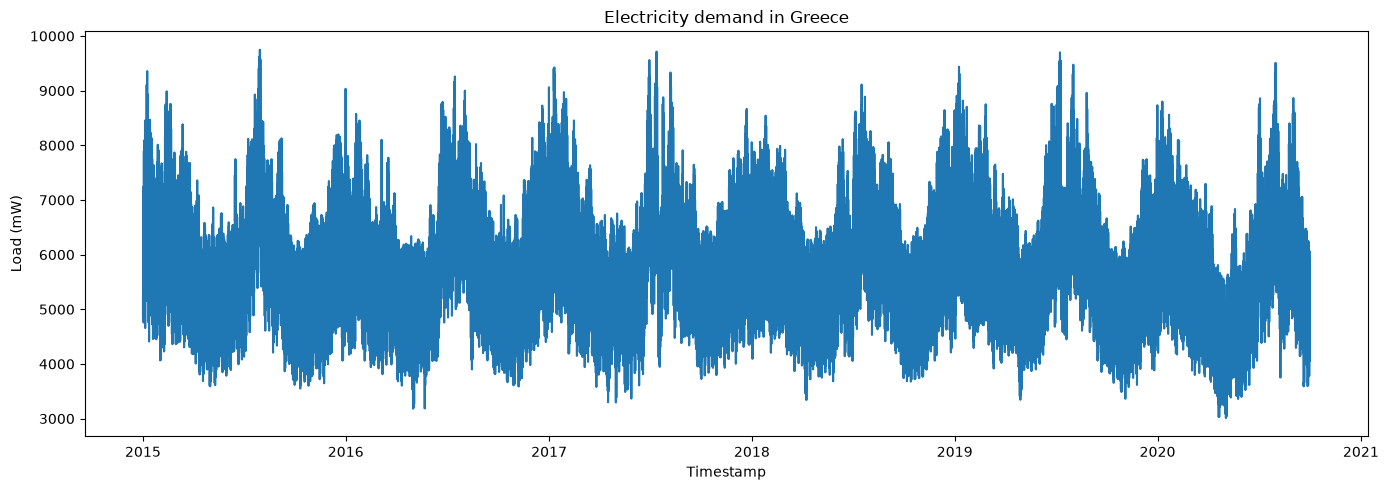

In [15]:
plt.figure(figsize=(14,5))

plt.plot(load_df["timestamp"], load_df["load_mw"])

plt.title("Electricity demand in Greece")
plt.xlabel("Timestamp")
plt.ylabel("Load (mW)")
plt.tight_layout()

plt.show()

A sample from January 2020

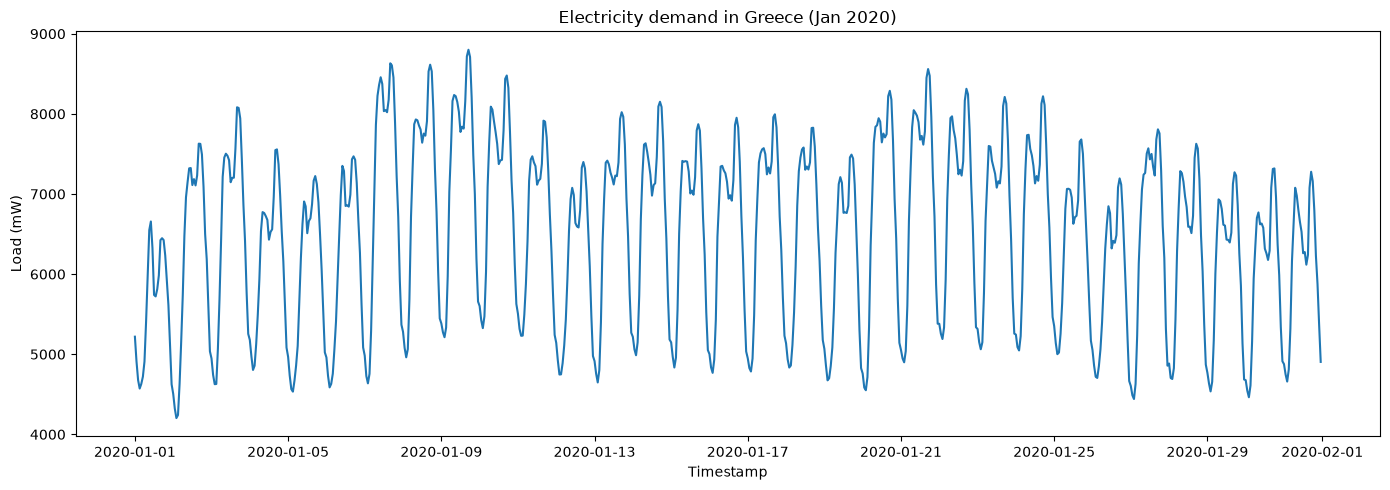

In [16]:
sample = load_df[
    (load_df["timestamp"] >= "2020-01-01") &
    (load_df["timestamp"] < "2020-02-01")
]

plt.figure(figsize=(14,5))
plt.plot(sample["timestamp"], sample["load_mw"])
plt.title("Electricity demand in Greece (Jan 2020)")
plt.xlabel("Timestamp")
plt.ylabel("Load (mW)")

plt.tight_layout()

plt.show()


# Inspection and analysis of missing values

In [17]:
missing = load_df[load_df["load_mw"].isna()]

missing

,timestamp,load_mw
0,2014-12-31 23:00:00+00:00,NaN
1,2015-01-01 00:00:00+00:00,NaN
10314,2016-03-05 17:00:00+00:00,NaN
10315,2016-03-05 18:00:00+00:00,NaN
10316,2016-03-05 19:00:00+00:00,NaN
10317,2016-03-05 20:00:00+00:00,NaN
10318,2016-03-05 21:00:00+00:00,NaN
12652,2016-06-11 03:00:00+00:00,NaN
12653,2016-06-11 04:00:00+00:00,NaN
12654,2016-06-11 05:00:00+00:00,NaN


In [18]:
missing["timestamp"].diff().value_counts()

timestamp
0 days 01:00:00       30
429 days 17:00:00      1
97 days 06:00:00       1
0 days 11:00:00        1
7 days 21:00:00        1
0 days 07:00:00        1
117 days 01:00:00      1
1446 days 03:00:00     1
Name: count, dtype: int64

In [19]:
missing["timestamp"].dt.year.value_counts().sort_index()

timestamp
2014     1
2015     1
2016    35
2020     1
Name: count, dtype: int64

# Create temporal features for EDA

In [20]:
load_df["local_timestamp"] = (
    load_df["timestamp"].dt.tz_convert("Europe/Athens")
)

In [21]:
load_df["year"] = load_df["local_timestamp"].dt.year
load_df["month"] = load_df["local_timestamp"].dt.month
load_df["hour"] = load_df["local_timestamp"].dt.hour
load_df["day_of_week"] = load_df["local_timestamp"].dt.dayofweek
load_df["is_weekend"] = load_df["day_of_week"] >= 5

# Average Demand per Hour

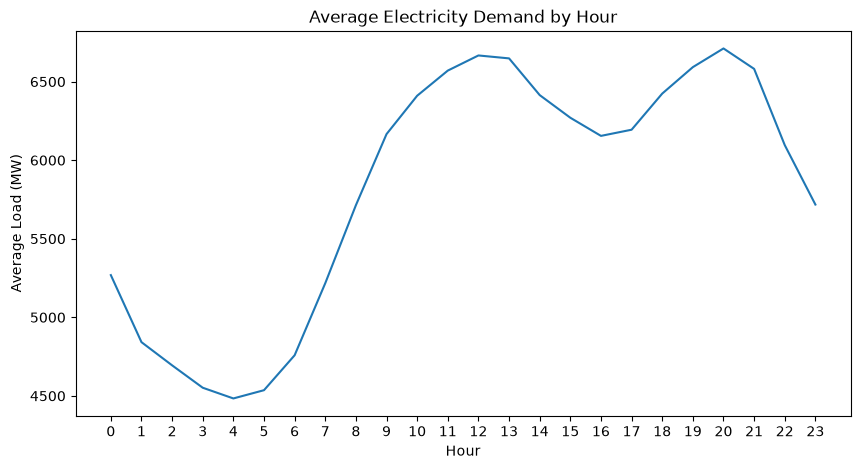

In [22]:
hourly_profile = load_df.groupby("hour")["load_mw"].mean()

hourly_profile.plot(figsize=(10, 5))
plt.title("Average Electricity Demand by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Load (MW)")
plt.xticks(range(24))
plt.show()

# Average demand by day of week

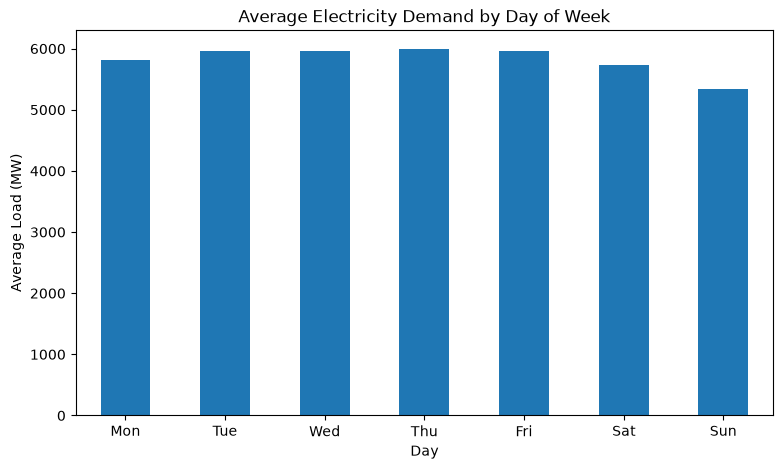

In [23]:
daily_profile = (
    load_df.groupby("day_of_week")["load_mw"]
    .mean()
)

daily_profile.plot(kind="bar", figsize=(9, 5))

plt.title("Average Electricity Demand by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Load (MW)")
plt.xticks(
    range(7),
    ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"],
    rotation=0
)

plt.show()

# Average demand by month

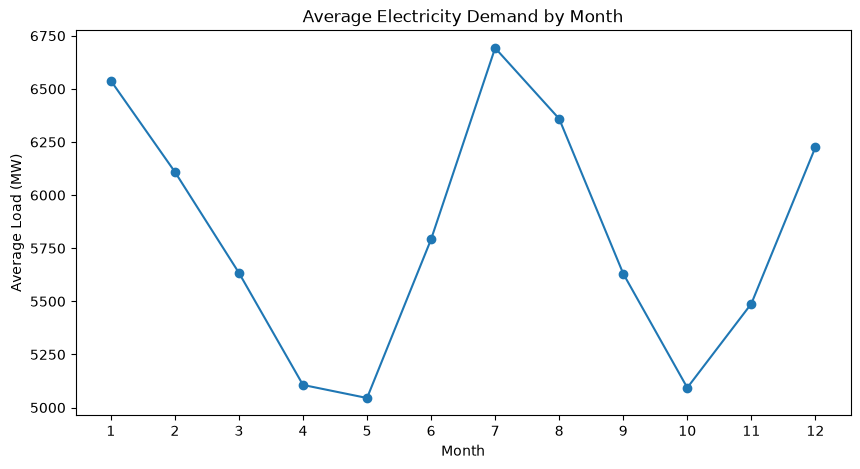

In [24]:
monthly_profile = load_df.groupby("month")["load_mw"].mean()

monthly_profile.plot(figsize=(10, 5), marker="o")

plt.title("Average Electricity Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Load (MW)")
plt.xticks(range(1, 13))

plt.show()

In [25]:
missing[["timestamp", "load_mw"]].to_string(index=False)

'                timestamp  load_mw\n2014-12-31 23:00:00+00:00      NaN\n2015-01-01 00:00:00+00:00      NaN\n2016-03-05 17:00:00+00:00      NaN\n2016-03-05 18:00:00+00:00      NaN\n2016-03-05 19:00:00+00:00      NaN\n2016-03-05 20:00:00+00:00      NaN\n2016-03-05 21:00:00+00:00      NaN\n2016-06-11 03:00:00+00:00      NaN\n2016-06-11 04:00:00+00:00      NaN\n2016-06-11 05:00:00+00:00      NaN\n2016-06-11 16:00:00+00:00      NaN\n2016-06-11 17:00:00+00:00      NaN\n2016-06-11 18:00:00+00:00      NaN\n2016-06-11 19:00:00+00:00      NaN\n2016-06-11 20:00:00+00:00      NaN\n2016-06-19 17:00:00+00:00      NaN\n2016-06-19 18:00:00+00:00      NaN\n2016-06-19 19:00:00+00:00      NaN\n2016-06-19 20:00:00+00:00      NaN\n2016-06-20 03:00:00+00:00      NaN\n2016-06-20 04:00:00+00:00      NaN\n2016-06-20 05:00:00+00:00      NaN\n2016-06-20 06:00:00+00:00      NaN\n2016-06-20 07:00:00+00:00      NaN\n2016-10-15 08:00:00+00:00      NaN\n2016-10-15 09:00:00+00:00      NaN\n2016-10-15 10:00:00+00:00  

# Encode hours of the day cyclically

In [26]:
load_df["hour_sin"] = np.sin(
    2 * np.pi * load_df["hour"] / 24
)

load_df["hour_cos"] = np.cos(
    2 * np.pi * load_df["hour"] / 24
)

In [27]:
from pandas.plotting import autocorrelation_plot

lags = [1, 2, 3, 6, 12, 24, 48, 72, 168]

for lag in lags:
    corr = load_df["load_mw"].corr(
        load_df["load_mw"].shift(lag)
    )
    
    print(f"Lag {lag:>3}h: {corr:.4f}")

Lag   1h: 0.9570
Lag   2h: 0.8571
Lag   3h: 0.7234
Lag   6h: 0.3262
Lag  12h: 0.1316
Lag  24h: 0.9234
Lag  48h: 0.8625
Lag  72h: 0.8331
Lag 168h: 0.8534


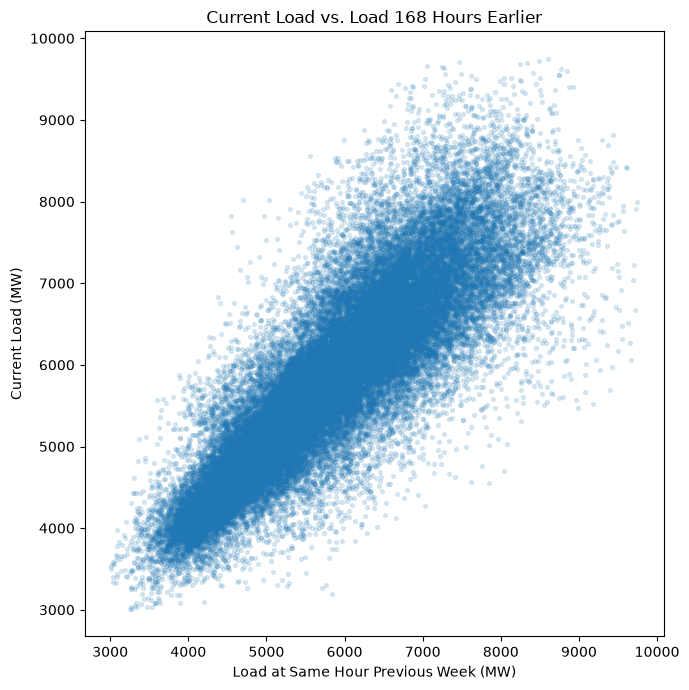

In [28]:
fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(
    load_df["load_mw"].shift(168),
    load_df["load_mw"],
    alpha=0.15,
    s=8
)

ax.set_xlabel("Load at Same Hour Previous Week (MW)")
ax.set_ylabel("Current Load (MW)")
ax.set_title("Current Load vs. Load 168 Hours Earlier")

plt.tight_layout()
plt.show()

# Fill the missing values

In [29]:
# Keep track of which values were filled up
load_df["was_imputed"] = load_df["load_mw"].isna()

load_df["load_mw_clean"] = load_df["load_mw"].copy()

missing_mask = load_df["load_mw_clean"].isna()

seasonal_fill = (
    load_df["load_mw_clean"].shift(168) +
    load_df["load_mw_clean"].shift(-168)
) / 2

load_df.loc[missing_mask, "load_mw_clean"] = seasonal_fill[missing_mask]

# Remove the boundary NaNs
load_df["was_imputed"] = load_df["load_mw"].isna()

# Sanity check after cleaning

In [30]:
load_df["load_mw_clean"].isna().sum()
load_df["was_imputed"].value_counts()

was_imputed
False    50363
True        38
Name: count, dtype: int64

# Columns adjustment

In [31]:
load_df = load_df.drop(columns=["load_mw"])

load_df = load_df.rename(
    columns={"load_mw_clean": "load_mw"}
)

In [32]:
load_df = load_df[
    [
        "timestamp",
        "load_mw",
        "was_imputed",
    ]
].copy()

In [33]:
load_df.head()
load_df.info()
load_df["load_mw"].isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 50401 entries, 0 to 50400
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   timestamp    50401 non-null  datetime64[us, UTC]
 1   load_mw      50398 non-null  float64            
 2   was_imputed  50401 non-null  bool               
dtypes: bool(1), datetime64[us, UTC](1), float64(1)
memory usage: 836.9 KB


np.int64(3)

In [34]:
load_df = load_df.dropna(subset=["load_mw"]).copy()

load_df = load_df.reset_index(drop=True)

load_df.info()

print("Missing values:", load_df["load_mw"].isna().sum())
print("Rows:", len(load_df))
print("Imputed:", load_df["was_imputed"].sum())

<class 'pandas.DataFrame'>
RangeIndex: 50398 entries, 0 to 50397
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype              
---  ------       --------------  -----              
 0   timestamp    50398 non-null  datetime64[us, UTC]
 1   load_mw      50398 non-null  float64            
 2   was_imputed  50398 non-null  bool               
dtypes: bool(1), datetime64[us, UTC](1), float64(1)
memory usage: 836.8 KB
Missing values: 0
Rows: 50398
Imputed: 35


In [35]:
load_df.to_csv(
    "../data/processed/greece_hourly_load.csv",
    index=False
)

### Dataset preparation overview

The electricity load series contained 38 missing observations out of 50,401
(~0.08%). Most missing values occurred in short, contiguous gaps, with the
largest gap spanning 13 hours.

Because electricity demand exhibits strong weekly seasonality, missing internal
observations were estimated using the load recorded at the same hour one week
before and one week after the missing timestamp:

$$
\hat{y}_t = \frac{y_{t-168} + y_{t+168}}{2}
$$

where $168 = 24 \times 7$ represents the number of hours in one week.

This approach preserves the hourly and weekly consumption patterns observed
during exploratory analysis and was preferred over simple linear interpolation,
particularly for multi-hour gaps.

A boolean `was_imputed` column was retained to identify reconstructed
observations. This allows imputed target values to be excluded from model
evaluation later in the project.

Three missing observations located at the boundaries of the dataset could not
be estimated using this method because observations from both adjacent weeks
were unavailable. Since they represented only 3 out of 50,401 observations,
they were removed.

After preprocessing, the cleaned dataset contains 50,398 hourly observations,
including 35 seasonally imputed values and no remaining missing load values.